In [23]:
import pandas as pd

In [24]:
column_names = [
    "buying",
    "maint",
    "doors",
    "persons",
    "lug_boot",
    "safety",
    "class"
 ]

car_data = pd.read_csv("car.csv", names=column_names)

print("First 5 rows of the dataset:")
print(car_data.head())

First 5 rows of the dataset:
  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc


In [25]:
print("Dataset information:")
car_data.info()

print("\nNumber of cars in each class:")
print(car_data["class"].value_counts())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB

Number of cars in each class:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [26]:
encoded_data = pd.get_dummies(car_data, drop_first=False)

print("Encoded version of the data:")
print(encoded_data.head())

Encoded version of the data:
   buying_high  buying_low  buying_med  buying_vhigh  maint_high  maint_low  \
0        False       False       False          True       False      False   
1        False       False       False          True       False      False   
2        False       False       False          True       False      False   
3        False       False       False          True       False      False   
4        False       False       False          True       False      False   

   maint_med  maint_vhigh  doors_2  doors_3  ...  lug_boot_big  lug_boot_med  \
0      False         True     True    False  ...         False         False   
1      False         True     True    False  ...         False         False   
2      False         True     True    False  ...         False         False   
3      False         True     True    False  ...         False          True   
4      False         True     True    False  ...         False          True   

   lug_boot_sma

In [27]:
x = pd.get_dummies(car_data.drop("class", axis=1))
y = car_data["class"]

print("Shape of x:", x.shape)
print("Shape of y:", y.shape)

Shape of x: (1728, 21)
Shape of y: (1728,)


In [28]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (1382, 21)
Testing data shape: (346, 21)


In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

decision_tree_model = DecisionTreeClassifier()
decision_tree_model.fit(x_train, y_train)

decision_tree_predictions = decision_tree_model.predict(x_test)
decision_tree_accuracy = accuracy_score(y_test, decision_tree_predictions)

print("Decision Tree Accuracy:", decision_tree_accuracy)

Decision Tree Accuracy: 0.9595375722543352


In [30]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, decision_tree_predictions))

Classification Report:
              precision    recall  f1-score   support

         acc       0.99      0.88      0.93        83
        good       0.62      0.91      0.74        11
       unacc       0.98      1.00      0.99       235
       vgood       0.82      0.82      0.82        17

    accuracy                           0.96       346
   macro avg       0.85      0.90      0.87       346
weighted avg       0.96      0.96      0.96       346



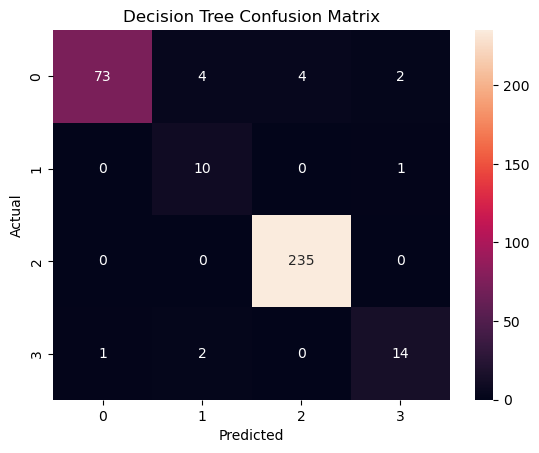

In [31]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

decision_tree_cm = confusion_matrix(y_test, decision_tree_predictions)

sns.heatmap(decision_tree_cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

logistic_model = LogisticRegression(max_iter=2000)
tree_model = DecisionTreeClassifier(random_state=42)
forest_model = RandomForestClassifier(n_estimators=200, random_state=42)
svm_model = SVC(kernel="rbf", random_state=42)

logistic_model.fit(x_train, y_train)
tree_model.fit(x_train, y_train)
forest_model.fit(x_train, y_train)
svm_model.fit(x_train, y_train)

logistic_predictions = logistic_model.predict(x_test)
logistic_accuracy = accuracy_score(y_test, logistic_predictions)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.9161849710982659


In [33]:
tree_predictions = tree_model.predict(x_test)
tree_accuracy = accuracy_score(y_test, tree_predictions)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.9566473988439307


In [34]:
forest_predictions = forest_model.predict(x_test)
forest_accuracy = accuracy_score(y_test, forest_predictions)

print("Random Forest Accuracy:", forest_accuracy)

Random Forest Accuracy: 0.9624277456647399


In [35]:
svm_predictions = svm_model.predict(x_test)
svm_accuracy = accuracy_score(y_test, svm_predictions)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9682080924855492


In [36]:
model_results = {
    "Logistic Regression": logistic_accuracy,
    "Decision Tree": tree_accuracy,
    "Random Forest": forest_accuracy,
    "SVM": svm_accuracy
}

print("Model results:")
print(model_results)

Model results:
{'Logistic Regression': 0.9161849710982659, 'Decision Tree': 0.9566473988439307, 'Random Forest': 0.9624277456647399, 'SVM': 0.9682080924855492}


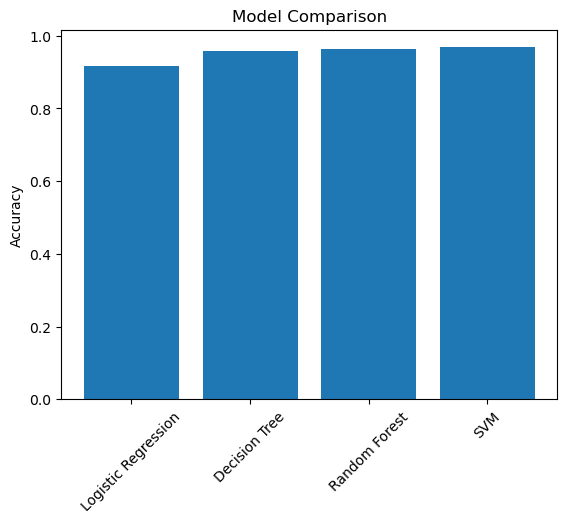

In [37]:
plt.bar(model_results.keys(), model_results.values())
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [38]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(forest_model, x, y, cv=5)

print("Cross validation accuracy:", cv_scores.mean())

Cross validation accuracy: 0.7593331657870487


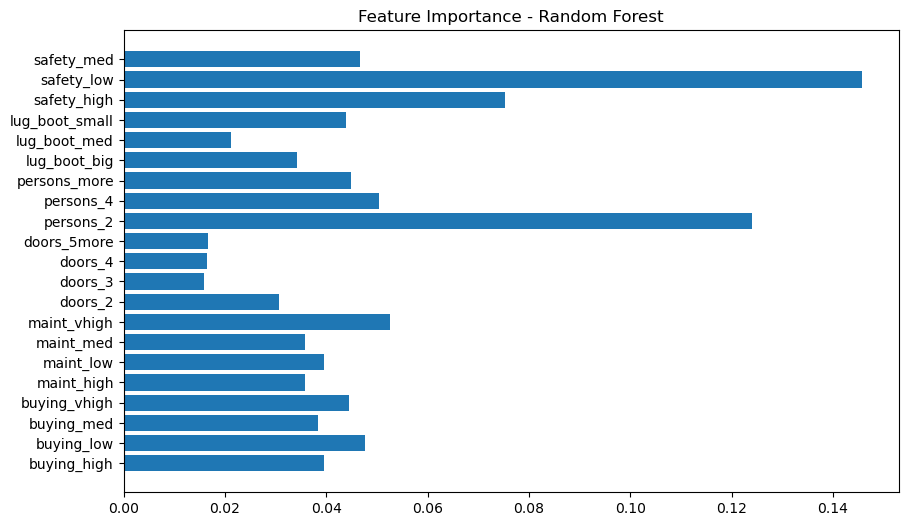

In [39]:
feature_importance_values = forest_model.feature_importances_
feature_names = x.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importance_values)
plt.title("Feature Importance - Random Forest")
plt.show()

In [40]:
from sklearn.metrics import accuracy_score

all_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model,
    "SVM": svm_model
}

final_results = {}

for model_name, current_model in all_models.items():
    current_predictions = current_model.predict(x_test)
    current_accuracy = accuracy_score(y_test, current_predictions)
    final_results[model_name] = current_accuracy

final_results

{'Logistic Regression': 0.9161849710982659,
 'Decision Tree': 0.9566473988439307,
 'Random Forest': 0.9624277456647399,
 'SVM': 0.9682080924855492}

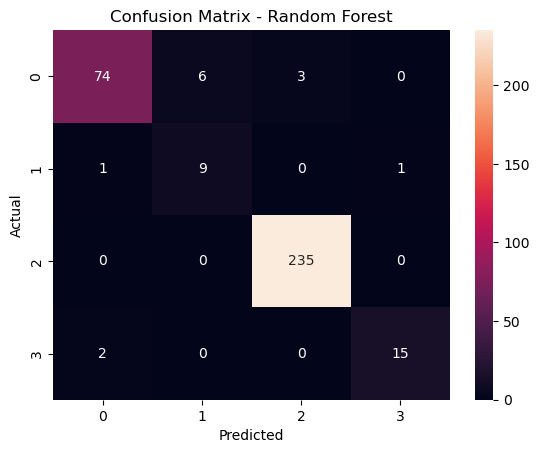

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_model = forest_model
best_model_predictions = best_model.predict(x_test)

best_model_cm = confusion_matrix(y_test, best_model_predictions)

sns.heatmap(best_model_cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

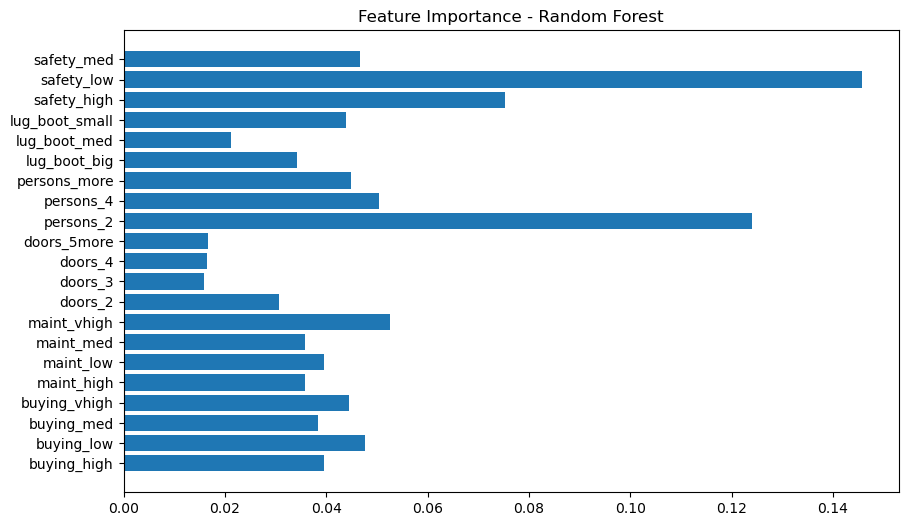

In [42]:
feature_importance_values = forest_model.feature_importances_
feature_names = x.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importance_values)
plt.title("Feature Importance - Random Forest")
plt.show()

In [43]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(forest_model, x, y, cv=5)
print("5-Fold CV Accuracy:", cv_scores.mean())

5-Fold CV Accuracy: 0.7593331657870487


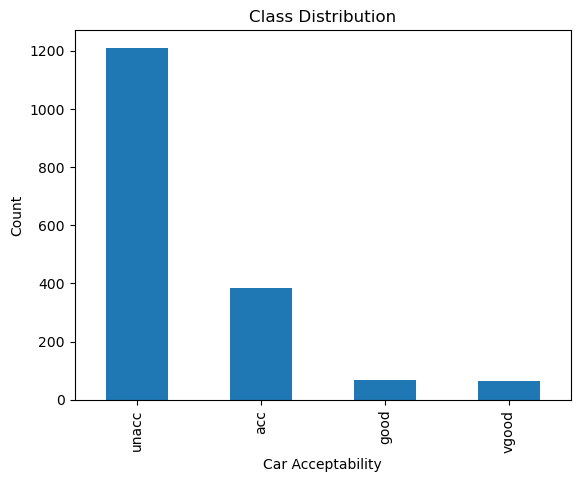

In [44]:
import matplotlib.pyplot as plt

car_data["class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Car Acceptability")
plt.ylabel("Count")
plt.show()